<span style = "font-family: Verdana; font-size: 20px">

#### **Visualization**
</span>

<span style = "font-family: Verdana; font-size: 20px">

##### **Init**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as mtick
from sklearn.manifold import TSNE
from PIL import Image
import openchord as ocd
from os import listdir

import unicodedata

<span style = "font-family: Verdana; font-size: 20px">

##### **Data reading**

In [3]:
data = pd.read_csv('../data/modified/viz_pokemon.csv', keep_default_na=False, dtype = {'ID': str})

<span style = "font-family: Verdana; font-size: 20px">

##### **Colors and functions defining**
</span>

In [4]:
STATS = ['Hp','Attack','Defense','SpecialAttack','SpecialDefense','Speed']


COLOR_TYPES = {'Normal': '#9fa19f',
               'Fighting': '#ff8101',
               'Flying': '#81b9ef',
               'Poison': '#9142cb',
               'Ground': '#925122',
               'Rock': '#a9af82',
               'Bug': '#91a119',
               'Ghost': '#714171',
               'Steel': '#61a1b9',
               'Fire': '#e72829',
               'Water': '#2881f0',
               'Grass': '#3fa22a',
               'Electric': '#fac000',
               'Psychic': '#f0417a',
               'Ice': '#3fcdf3',
               'Dragon': '#5060e2',
               'Dark': '#624d4f',
               'Fairy': '#ef71ef'
               }

COLOR_STATS = {'Hp': '#11ad1e',
               'Attack': '#ff0000',
               'Defense': '#ff9500',
               'SpecialAttack': '#00ddff',
               'SpecialDefense': '#3a12c9',
               'Speed': '#ea00ff',
               'TotalStats': '#8c00ff'
               }

COLOR_EGGGROUPS = {'Monster': '#98734d',
               'Human-Like': '#47b7ae',
               'Water 1': '#6bd1f9',
               'Water 3': '#2271b4',
               'Bug': '#abc229',
               'Mineral': '#979067',
               'Flying': '#90aff1',
               'Amorphous': '#a082cc',
               'Field': '#e5ba65',
               'Water 2': '#4c94ee',
               'Fairy': '#ff9eb9',
               'Ditto': '#b6aad5',
               'Grass': '#83d35a',
               'Dragon': '#5e58bf',
               'No Eggs Discovered': '#efd004',
               }

NUM_GEN = data['Generation'].max()

In [11]:
ICONSPATH = '../Images/Icons/'

def transformpath(path):
    if path == f'{ICONSPATH}/Type: Null.png':
        path = f'{ICONSPATH}/Type Null.png'
    elif path == f'{ICONSPATH}/Silvally Type: Normal.png':
        path = f'{ICONSPATH}/Silvally.png'  
    norm_form = 'NFC' if os.name == 'nt' else 'NFD'
    return unicodedata.normalize(norm_form, path)

for name in data['Name'].to_list():
    p = transformpath(f'{ICONSPATH}/{name}.png')
    assert os.path.isfile(p) or os.path.isfile(p), f"Icon not found for '{name}': {p}"

<span style = "font-family: Verdana; font-size: 20px">

##### **Ideas(?)**

- Difference between offensive and defensive stats.
- Ratio between physical/special stats.
- Graph study where pokemons are related when they have similar movements, and the weight of the arc depends on the proportion of shared movements.
- Evolution stage graphics.
</span>

<span style = "font-family: Verdana; font-size: 20px">

##### **Data Overview**

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  800 non-null    object 
 1   Name                800 non-null    object 
 2   Type1               800 non-null    object 
 3   Type2               800 non-null    object 
 4   HiddenAbility       800 non-null    object 
 5   Generation          800 non-null    int64  
 6   Hp                  800 non-null    float64
 7   Attack              800 non-null    float64
 8   Defense             800 non-null    float64
 9   SpecialAttack       800 non-null    float64
 10  SpecialDefense      800 non-null    float64
 11  Speed               800 non-null    float64
 12  TotalStats          800 non-null    float64
 13  Weight              800 non-null    float64
 14  Height              800 non-null    float64
 15  GenderProbM         800 non-null    float64
 16  Category

In [13]:
pd.options.display.max_columns = None
data

,ID,Name,Type1,Type2,HiddenAbility,Generation,Hp,Attack,Defense,SpecialAttack,SpecialDefense,Speed,TotalStats,Weight,Height,GenderProbM,Category,CatchRate,EggCycles,LevelingRate,BaseFriendship,IsLegendary,IsMythical,HasMega,EvoStage,TotalEvoStages,PreevoName,DamageFromNormal,DamageFromFighting,DamageFromFlying,DamageFromPoison,DamageFromGround,DamageFromRock,DamageFromBug,DamageFromGhost,DamageFromSteel,DamageFromFire,DamageFromWater,DamageFromGrass,DamageFromElectric,DamageFromPsychic,DamageFromIce,DamageFromDragon,DamageFromDark,DamageFromFairy,Ability1,Ability2,NoGender,EggGroup1,EggGroup2,IsMega,FightsWon,TotalFights,WinPercentage
0,1,Bulbasaur,Grass,Poison,Chlorophyll,1,45.0,49.0,49.0,65.0,65.0,45.0,318.0,6.9,0.7,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,0,1,3,No Preevolution,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,37,133,0.278195
1,2,Ivysaur,Grass,Poison,Chlorophyll,1,60.0,62.0,63.0,80.0,80.0,60.0,405.0,13.0,1.0,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,0,2,3,Bulbasaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,46,121,0.380165
2,3,Venusaur,Grass,Poison,Chlorophyll,1,80.0,82.0,83.0,100.0,100.0,80.0,525.0,100.0,2.0,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,1,3,3,Ivysaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,89,132,0.674242
3,4,Mega Venusaur,Grass,Poison,None,1,80.0,100.0,123.0,122.0,120.0,80.0,625.0,155.5,2.4,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,1,3,3,Venusaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,0.5,0.25,0.5,2.0,1.00,1.0,1.0,0.5,Thick Fat,None,0,Monster,Grass,1,70,125,0.560000
4,5,Charmander,Fire,Fire,Solar Power,1,39.0,52.0,43.0,60.0,50.0,65.0,309.0,8.5,0.6,0.875,Lizard Pokémon,45,20,Medium Slow,70,0,0,0,1,3,No Preevolution,1.0,1.0,1.0,1.0,2.0,2.0,0.5,1.0,0.50,0.50,2.0,0.50,1.0,1.0,0.50,1.0,1.0,0.5,Blaze,None,0,Monster,Dragon,0,55,112,0.491071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Diancie,Rock,Fairy,None,6,50.0,100.0,150.0,100.0,150.0,50.0,600.0,8.8,0.7,0.500,Jewel Pokémon,3,25,Slow,70,0,1,1,1,1,No Preevolution,0.5,1.0,0.5,1.0,2.0,1.0,0.5,1.0,4.00,0.50,2.0,2.00,1.0,1.0,1.00,0.0,0.5,1.0,Clear Body,None,1,No Eggs Discovered,No Eggs Discovered,0,39,105,0.371429
796,797,Mega Diancie,Rock,Fairy,None,6,50.0,160.0,110.0,160.0,110.0,110.0,700.0,27.8,1.1,0.500,Jewel Pokémon,3,25,Slow,0,0,1,1,1,1,Diancie,0.5,1.0,0.5,1.0,2.0,1.0,0.5,1.0,4.00,0.50,2.0,2.00,1.0,1.0,1.00,0.0,0.5,1.0,Magic Bounce,None,1,No Eggs Discovered,No Eggs Discovered,1,116,131,0.885496
797,798,Hoopa Confined,Psychic,Ghost,None,6,80.0,110.0,60.0,150.0,130.0,70.0,600.0,9.0,0.5,0.500,Mischief Pokémon,3,120,Slow,100,0,1,0,1,1,No Preevolution,0.0,0.0,1.0,0.5,1.0,1.0,1.0,4.0,1.00,1.00,1.0,1.00,1.0,0.5,1.00,1.0,4.0,1.0,Magician,None,1,No Eggs Discovered,No Eggs Discovered,0,60,119,0.504202
798,799,Hoopa Unbound,Psychic,Dark,None,6,80.0,160.0,60.0,170.0,130.0,80.0,680.0,9.0,0.5,0.500,Mischief Pokémon,3,120,Slow,100,0,1,0,1,1,No Preevolution,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,1.00,1.00,1.0,1.00,1.0,0.0,1.00,1.0,1.0,2.0,Magician,None,1,No Eggs Discovered,No Eggs Discovered,0,89,144,0.618056


<span style = "font-family: Verdana; font-size: 20px">

**Variable Classification**

In [ ]:
numeric_columns = ['Generation', 
                   'Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed', 'TotalStats',
                   'Height', 'Weight', 'GenderProbM', 'CatchRate', 'EggCycles',
                   'BaseFriendship', 'EvoStage', 'TotalEvoStages',
                   'FightsWon', 'TotalFights', 'WinPercentage',
                   'DamageFromNormal', 'DamageFromFighting', 'DamageFromFlying', 'DamageFromPoison',
                   'DamageFromGround', 'DamageFromRock', 'DamageFromBug', 'DamageFromGhost',
                   'DamageFromSteel', 'DamageFromFire', 'DamageFromWater', 'DamageFromGrass',
                   'DamageFromElectric', 'DamageFromPsychic', 'DamageFromIce', 'DamageFromDragon', 
                   'DamageFromDark', 'DamageFromFairy']

categorical_columns = ['Name', 'Type1', 'Type2', 'Ability1', 'Ability2', 'HiddenAbility',
                       'Category', 'EggGroup1', 'EggGroup2', 
                       'LevelingRate', 'PreevoName']

binary_columns = ['IsLegendary', 'IsMythical', 
                  'HasMega', 'IsMega',
                  'NoGender']

ordinal_columns = []

<span style = "font-family: Verdana; font-size: 20px">

##### **Numerical Features**

In [15]:
def num_histogram(data, feature, lineartick = False):
    df = data.groupby(feature).value_counts().reset_index(name='Count')
    
    fig = go.Figure(px.histogram(df,
                                 x = feature,
                                 y = 'Count',
                                 ))
    fig.update_layout(bargap = 0.1,
                      yaxis_title = dict(text='Count'),
                      title = dict(
                          text = f'<br>Distribution of {feature}',
                          font = dict(size=16)
                          ),
    )
    if lineartick:
        fig.update_xaxes(tickmode='linear')
    else:
        pass
    fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Number of Pokémon by type/generation**

In [ ]:
filter_df = data.copy()
filter_df['Type2'] = filter_df.apply(lambda row: '' if row['Type1'] == row['Type2'] else row['Type2'], axis=1)

In [ ]:
d1 = filter_df.groupby('Generation')['Type1'].value_counts().reset_index(name ='Count')
d2 = filter_df.groupby('Generation')['Type2'].value_counts().reset_index(name ='Count')

n_type = d1.copy()
n_type = n_type.rename({'Type1': 'Type'}, axis=1)

for gen in range(1, NUM_GEN+1):
    for poktype in COLOR_TYPES.keys():
        if n_type.loc[(n_type["Type"] == poktype) & (n_type["Generation"] == gen), 'Count'].empty:
            n_type.loc[len(n_type.index)] = [gen, poktype, 0.0]
        if not d2.loc[(d2["Type2"] == poktype) & (d2["Generation"] == gen), 'Count'].empty:
            n_type.loc[(n_type["Type"] == poktype) & (n_type["Generation"] == gen), 'Count'] += d2.loc[(d2["Type2"] == poktype) & (d2["Generation"] == gen), 'Count'].values[0]
n_type['Generation'] = n_type['Generation'].replace({1: 'I', 2: 'II', 3: 'III', 4: 'IV', 5: 'V', 6: 'VI'})
# print(d1, d2)
# print(n_type)

In [45]:
fig = go.Figure(px.histogram(n_type, 
                                 y = "Type",
                                 x = "Count", 
                                 color = "Type", 
                                 title = "Wide-Form Input", 
                                 color_discrete_map=COLOR_TYPES))
fig.update_layout(bargap = 0.1,
    yaxis_title = dict(text='Type'),
    xaxis_title = dict(text='Number of Pokémon by type'),
    title=dict(
                text = f"<br>Number of Pokémon by type",
                font = dict(
                    size = 16
                )
            ),
    title_x=0.5,
)
fig.show()

fig = fig=go.Figure(px.histogram(n_type, 
                                 y="Generation",
                                 x="Count", 
                                 color="Generation", 
                                 title="Wide-Form Input", 
                                 color_discrete_map=COLOR_TYPES))
fig.update_layout(bargap=0.2,
    yaxis_title=dict(text='Generation'),
    xaxis_title=dict(text='Number of Pokémon by Generation'),
    title=dict(
                text=f"<br>Number of Pokémon by Generation",
                font=dict(
                    size=16
                )
            ),
    title_x=0.5,
)
fig.show()

In [ ]:
wide_df = px.data.medals_wide()

fig = go.Figure(px.histogram(n_type, x="Generation", y="Count", color="Type", title="Wide-Form Input", color_discrete_map=COLOR_TYPES, width=800, height=650))
fig.update_layout(bargap=0.02,
        xaxis_title=dict(text='Generation'),
        yaxis_title=dict(text='Number of Pokémon by type'),
        title=dict(
                    text=f"<br>Number of Pokémon by type in each generation",
                    font=dict(
                        size=16
                    )
                ),
        title_x=0.5,
)
fig.show()
fig.write_image(f"../Images/Graphics/NumPokemonByGen.png", width=600, height=550)

<span style = "font-family: Verdana; font-size: 20px">

**Basic Stats**

<span style = "font-family: Verdana; font-size: 16px">

**Top 10 Pokémons with highest value in each stat**

In [21]:
for stat in STATS:
    print(stat)
    display(data[['Name', stat]].sort_values(stat, ascending=False).head(10))

Hp


,Name,Hp
261,Blissey,255.0
121,Chansey,250.0
217,Wobbuffet,190.0
351,Wailord,170.0
655,Alomomola,165.0
155,Snorlax,160.0
544,Giratina Altered Forme,150.0
473,Drifblim,150.0
545,Giratina Origin Forme,150.0
313,Slaking,150.0


Attack


,Name,Attack
163,Mega Mewtwo X,190.0
232,Mega Heracross,185.0
424,Primal Groudon,180.0
426,Mega Rayquaza,180.0
429,DeoxysAttack Forme,180.0
711,Kyurem Black Kyurem,170.0
494,Mega Garchomp,170.0
527,Mega Gallade,165.0
387,Mega Banette,165.0
454,Rampardos,165.0


Defense


...

,Name,SpecialAttack
164,Mega Mewtwo Y,194.0
429,DeoxysAttack Forme,180.0
426,Mega Rayquaza,180.0
422,Primal Kyogre,180.0
71,Mega Alakazam,175.0
712,Kyurem White Kyurem,170.0
102,Mega Gengar,170.0
798,Hoopa Unbound,170.0
196,Mega Ampharos,165.0
306,Mega Gardevoir,165.0


SpecialDefense


,Name,SpecialDefense
230,Shuckle,230.0
415,Regice,200.0
422,Primal Kyogre,160.0
430,Deoxys Defense Forme,160.0
739,Florges,154.0
270,Ho-oh,154.0
269,Lugia,154.0
418,Mega Latias,150.0
773,Carbink,150.0
416,Registeel,150.0


Speed


,Name,Speed
431,Deoxys Speed Forme,180.0
315,Ninjask,160.0
154,Mega Aerodactyl,150.0
109,Electrode,150.0
71,Mega Alakazam,150.0
428,Deoxys Normal Forme,150.0
429,DeoxysAttack Forme,150.0
19,Mega Beedrill,145.0
678,Accelgor,145.0
275,Mega Sceptile,145.0


<span style = "font-family: Verdana; font-size: 16px">

**Basic stat distribution**

In [22]:
def stat_boxplot(data, stat):
    # Build a dataframe with one row per Pokémon-stat value and its corresponding type (Type1 or Type2)
    types = []
    values = []
    for t in COLOR_TYPES.keys():
        mask_t = (data['Type1'] == t) | (data['Type2'] == t)
        if mask_t.any():
            types.extend([t] * int(mask_t.sum()))
            values.extend(data.loc[mask_t, stat].tolist())
    df_plot = pd.DataFrame({'Type': types, stat: values})

    fig = go.Figure()
    fig.add_trace(go.Box(
        x=df_plot['Type'],
        y=df_plot[stat],
        boxpoints='outliers',
        jitter=0,
        pointpos=0,
        marker_color=COLOR_STATS[stat],
        line_color=COLOR_STATS[stat],
        name=stat
    ))
    fig.update_layout(
        title=dict(
            text=f"<br>Boxplot of {stat}",
            font=dict(size=16)
        ),
        xaxis_title=dict(text='Type'),
        yaxis_title=dict(text=stat),
        showlegend=False,
        xaxis=dict(tickangle=-90)
    )
    fig.update_xaxes(categoryorder='array', categoryarray=list(COLOR_TYPES.keys()))
    fig.show()
    

In [23]:
stat_cols = STATS.copy()
for stat in stat_cols:
    stat_boxplot(data, stat)

In [24]:
max_mean_stat = 0
for t in COLOR_TYPES.keys():
    fig = go.Figure()
    data_type_1 = data.loc[data['Type1'] == t]
    data_type_2 = data.loc[data['Type2'] == t]
    total_data_type = pd.concat([data_type_1, data_type_2])
    mean_stats = [total_data_type[x].mean() for x in STATS]
    for elem in mean_stats:
        if elem > max_mean_stat:
            max_mean_stat = elem

In [25]:
mean_values_df = pd.DataFrame(columns=STATS)

for t in COLOR_TYPES.keys():
    fig = go.Figure()
    data_type_1 = data.loc[data['Type2'] == t]
    data_type_2 = data.loc[data['Type2'] == t]
    total_data_type = pd.concat([data_type_1, data_type_2])
    mean_stats = [total_data_type[x].mean() for x in STATS]
    mean_values_df.loc[t] = mean_stats
    fig = px.bar(x=STATS, y=mean_stats,
                 color=STATS, color_discrete_map=COLOR_STATS,
                 labels=dict(x="Stats", y="Mean stat value", color="Stats color"))
    fig.update_layout(
    title=dict(
                text=f"Mean statistics for type {t}",
                font=dict(
                    size=16
                )),
    title_x=0.5,
    yaxis_range=[0,max_mean_stat]
    )
    
    fig.show()

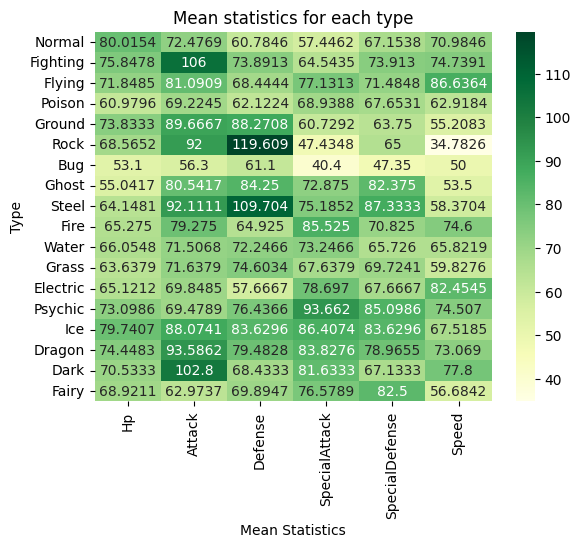

In [26]:
fig, ax = plt.subplots()

sns.heatmap(mean_values_df, annot=True, cmap='YlGn', fmt='g')
plt.title('Mean statistics for each type')
plt.xlabel('Mean Statistics')
plt.ylabel('Type')
plt.show()
fig.savefig('../Images/Graphics/MeanStatsType.png', bbox_inches='tight')

In [27]:
mean_values_df.transpose()

for stat in STATS:
    fig = px.bar(mean_values_df[stat], title=f"Mean statistics for stat {stat}.",
                 color=COLOR_TYPES.keys(), color_discrete_map=COLOR_TYPES,
                 labels=dict(index="Type", value=f"Mean {stat}", color="Type color"))
    fig.update_layout(
    barmode = "stack",
    title = dict(
                text = f"<br>Sum of mean stats by type",
                font = dict(
                    size = 16
                )),
    title_x = 0.5,
    yaxis_range = [0,max_mean_stat],
    xaxis = dict(tickangle = -90,
                 categoryorder = 'total descending')
    )
    fig.show()

In [28]:
fig = go.Figure()

new_mean_values_df = mean_values_df
new_mean_values_df.mean()

for i, stat in enumerate(new_mean_values_df.columns):
    fig.add_trace(go.Bar(
        x=new_mean_values_df.index,
        y=new_mean_values_df[stat],
        name=stat,
        marker=dict(color=COLOR_STATS[stat])
    ))

fig.update_layout(
    barmode="stack",
    title=dict(
                text=f"<br>Sum of all mean stats by type",
                font=dict(
                    size=16
                )),
    title_x=0.5,
    xaxis_title="Type",
    yaxis_title="Mean stats",
    xaxis= dict(tickangle=-90,
                categoryorder='total descending')
)

fig.show()

<span style = "font-family: Verdana; font-size: 16px">

**Physical/Special Offensive/Defensive stat scatter density**

<span style = "font-family: Verdana; font-size: 16px">

Chỉ nhìn vào một chỉ số duy nhất thì khó mà kết luận được Pokémon đó có thực sự tốt hay không, vì nó có thể cao ở chỉ số này nhưng lại thấp ở chỉ số khác. Do đó trong cộng đồng có một thuật ngữ là `sweeper` và `wall`. `Sweeper` là những Pokémon có chỉ số tấn công cao, giúp chúng có thể nhanh chóng hạ gục đối thủ. Còn `wall` là những Pokémon có chỉ số phòng thủ cao.

Do đó chúng ta sẽ giả định các chỉ số trên được tính bằng công thức sau:
- Physical Offensive (Physical Sweeper) = $\sqrt{Attack*Speed}$
- Special Offensive (Special Sweeper) = $\sqrt{Special Attack*Speed}$
- Physical Defensive (Physical Wall) = $\sqrt{Defense*HP}$
- Special Defensive (Special Wall) = $\sqrt{Special Defense*HP}$

Lưu ý: Những chỉ số này sẽ chỉ xuất hiện để phục vụ việc trực quan hoá, không dùng để huấn luyện mô hình vì có khả năng gây đa cộng tuyến
</span>

In [29]:
def density_scatter(stat1, stat2, colorbase, colorend, titleadd):
    fig = go.Figure()
    
    fig = px.scatter(
        data,
        x = stat1,
        y = stat2,
        marginal_x = 'histogram',
        marginal_y = 'histogram',
        hover_name= 'Name',
        color_discrete_sequence=[colorend]
        )
    
    name = 'Name'
    
    for i in range(data.shape[0]):
        fig.add_layout_image(
            x = data.at[i, stat1],
            y = data.at[i, stat2],
            source = Image.open(transformpath(f'{ICONSPATH}/{data.at[i, name]}.png')),
            xref = "x",
            yref = "y",
            sizex = 7,
            sizey = 7,
            xanchor = "center",
            yanchor = "middle",
        )
        
    fig.update_traces(
        marker=dict(
            size = 0.1,
            opacity = 0.0,
            color = (data[stat1] * data[stat1] + data[stat2] * data[stat2]).apply(np.sqrt),
            colorscale = [[0, colorbase], [1, colorend]],
            line = dict(
                width = 1,
                color = (data[stat1] * data[stat1] + data[stat2] * data[stat2]).apply(np.sqrt),
                colorscale = [[0, colorbase], [1, colorend]]
            )
        ),
        selector = dict(mode = 'markers')
    )

    x = data[stat1]
    y = data[stat2]
    # names = data['Name']
    
    # print((x.max()-x.min())/5)
    
    fig.add_trace(go.Histogram2d(
        x = x,
        y = y,
        colorscale = [[0, colorbase], [1, colorend]],
        zmax = None,
        nbinsx = int((x.max()-x.min())/5),
        nbinsy = int((y.max()-y.min())/5),
        zauto = True,
        hoverinfo = 'skip'    
        )
    )
    
    fig.update_layout(
        xaxis = dict(
            ticks = '',
            showgrid = False,
            zeroline = False,
            nticks = 20
        ),
        yaxis = dict(
            ticks = '',
            showgrid = False,
            zeroline = False,
            nticks = 20
        ),
        autosize = False,
        width = 1000,
        height = 1000,
        hovermode = 'closest',
        xaxis_title = dict(text = stat1),
        yaxis_title = dict(text = stat2),
        title = dict(
            text =  f'<br>Pokémon {titleadd} ({stat1} vs {stat2})',
            font = dict(size = 16)
        ),
        title_x = 0.5,
        # plot_bgcolor = 'light_blue'
        coloraxis_colorbar = dict(
            title = 'Population',
            tickvals = [6, 7, 8, 9],
            ticktext = ['1M', '10M', '100M', '1B']
        )
    )
    x1_, x2_ = 0.91, 0.915
    y1_, y2_ = 0.91, 0.915
    
    fig.layout.xaxis.domain = (0, x1_)  #type: ignore
    fig.layout.xaxis2.domain = (x2_, 1) #type: ignore
    fig.layout.xaxis3.domain = (0, x1_) #type: ignore
    fig.layout.xaxis4.domain = (x2_, 1) #type: ignore
    fig.layout.yaxis.domain = (0, y1_)  #type: ignore
    fig.layout.yaxis2.domain = (0, y1_) #type: ignore
    fig.layout.yaxis3.domain = (y2_, 1) #type: ignore
    fig.layout.yaxis4.domain = (y2_, 1) #type: ignore
    
    fig.update(layout_coloraxis_showscale = False)
    
    fig.update_traces(showlegend = False)
    fig.update(layout_showlegend = False)
    
    fig.show()
    fig.write_image(f"../Images/Graphics/{titleadd}.png")
    
density_scatter("Speed", "Attack", "#ffffff", "#ff0000", 'Physical Offensiveness')
density_scatter("Speed", "SpecialAttack", "#ffffff", "#ffa500", 'Special Offensiveness')
density_scatter("Hp", "Defense", "#ffffff", "#32b000", 'Physical Defensiveness')
density_scatter("Hp", "SpecialDefense", "#ffffff", "#0000ff", 'Special Defensiveness')

<span style = "font-family: Verdana; font-size: 16px">

**Top 10 Pokémons with highest value in Physical/Special Offensive/Defensive stat**

In [30]:
data['PhysicalOffensiveness'] = (data['Attack'] * data['Speed']).apply(np.sqrt)
data['SpecialOffensiveness'] = (data['SpecialAttack'] * data['Speed']).apply(np.sqrt)
data['PhysiscalDefensiveness'] = (data['Defense'] * data['Hp']).apply(np.sqrt)
data['SpecialDefensiveness'] = (data['SpecialDefense'] * data['Hp']).apply(np.sqrt)

for stat in ['PhysicalOffensiveness', 'SpecialOffensiveness', 'PhysiscalDefensiveness', 'SpecialDefensiveness']:
    print(stat)
    display(data[['Name', stat]].sort_values(stat, ascending=False).head(10))

PhysicalOffensiveness


,Name,PhysicalOffensiveness
429,DeoxysAttack Forme,164.316767
163,Mega Mewtwo X,157.162336
428,Deoxys Normal Forme,150.000000
19,Mega Beedrill,147.478812
164,Mega Mewtwo Y,144.913767
426,Mega Rayquaza,143.874946
154,Mega Aerodactyl,142.302495
476,Mega Lopunny,135.499077
527,Mega Gallade,134.721936
796,Mega Diancie,132.664992


SpecialOffensiveness


,Name,SpecialOffensiveness
164,Mega Mewtwo Y,164.802913
429,DeoxysAttack Forme,164.316767
71,Mega Alakazam,162.018517
428,Deoxys Normal Forme,150.000000
102,Mega Gengar,148.660687
275,Mega Sceptile,145.000000
426,Mega Rayquaza,143.874946
163,Mega Mewtwo X,141.492049
162,Mewtwo,141.492049
339,Mega Manectric,135.000000


PhysiscalDefensiveness


,Name,PhysiscalDefensiveness
544,Giratina Altered Forme,134.164079
789,Avalugg,132.211951
224,Mega Steelix,131.339255
87,Mega Slowbro,130.766968
333,Mega Aggron,126.885775
414,Regirock,126.491106
424,Primal Groudon,126.491106
313,Slaking,122.474487
268,Mega Tyranitar,122.474487
545,Giratina Origin Forme,122.474487


SpecialDefensiveness


,Name,SpecialDefensiveness
261,Blissey,185.539753
121,Chansey,162.018517
544,Giratina Altered Forme,134.164079
155,Snorlax,132.664992
270,Ho-oh,127.765410
269,Lugia,127.765410
415,Regice,126.491106
422,Primal Kyogre,126.491106
545,Giratina Origin Forme,122.474487
546,Cresselia,120.000000


<span style = "font-family: Verdana; font-size: 16px">

**Stats summary**

In [31]:
for stat in STATS:
    print(f"Stat: {stat}")
    print(f"\t- The type with the greatest {stat} is {new_mean_values_df[stat].idxmax()} with a value of {new_mean_values_df[stat].max()}.")
    print(f"\t- The type with the lowest {stat} is {new_mean_values_df[stat].idxmin()} with a value of {new_mean_values_df[stat].min()}.")
    print(f"\t- This is {abs(new_mean_values_df[stat].max() - new_mean_values_df[stat].min())} units greater, or {abs(new_mean_values_df[stat].max()/new_mean_values_df[stat].min())} times greater.")

final_mean_values_df = new_mean_values_df.mean(axis=1)
print("\n")
print(f"The type with the greatest mean statistics is {final_mean_values_df.idxmax()} with a value of {final_mean_values_df.max()}.")
print(f"The type with the lowest mean statistics is {final_mean_values_df.idxmin()} with a value of {final_mean_values_df.min()}.")
print(f"This is {abs(final_mean_values_df.max() - final_mean_values_df.min())} units greater, or {abs(final_mean_values_df.max()/final_mean_values_df.min())} times greater.")

Stat: Hp
	- The type with the greatest Hp is Normal with a value of 80.01538461538462.
	- The type with the lowest Hp is Bug with a value of 53.1.
	- This is 26.915384615384617 units greater, or 1.5068810662031 times greater.
Stat: Attack
	- The type with the greatest Attack is Fighting with a value of 106.0.
	- The type with the lowest Attack is Bug with a value of 56.3.
	- This is 49.7 units greater, or 1.882770870337478 times greater.
Stat: Defense
	- The type with the greatest Defense is Rock with a value of 119.6086956521739.
	- The type with the lowest Defense is Electric with a value of 57.666666666666664.
	- This is 61.94202898550724 units greater, or 2.0741392309625533 times greater.
Stat: SpecialAttack
	- The type with the greatest SpecialAttack is Psychic with a value of 93.66197183098592.
	- The type with the lowest SpecialAttack is Bug with a value of 40.4.
	- This is 53.26197183098592 units greater, or 2.31836563938084 times greater.
Stat: SpecialDefense
	- The type with 

<span style = "font-family: Verdana; font-size: 16px">

**Total Stats**

In [32]:
data['TotalStats'].value_counts()

TotalStats
600.0    37
405.0    25
500.0    25
580.0    24
300.0    19
         ..
194.0     1
565.0     1
467.0     1
302.0     1
514.0     1
Name: count, Length: 198, dtype: int64

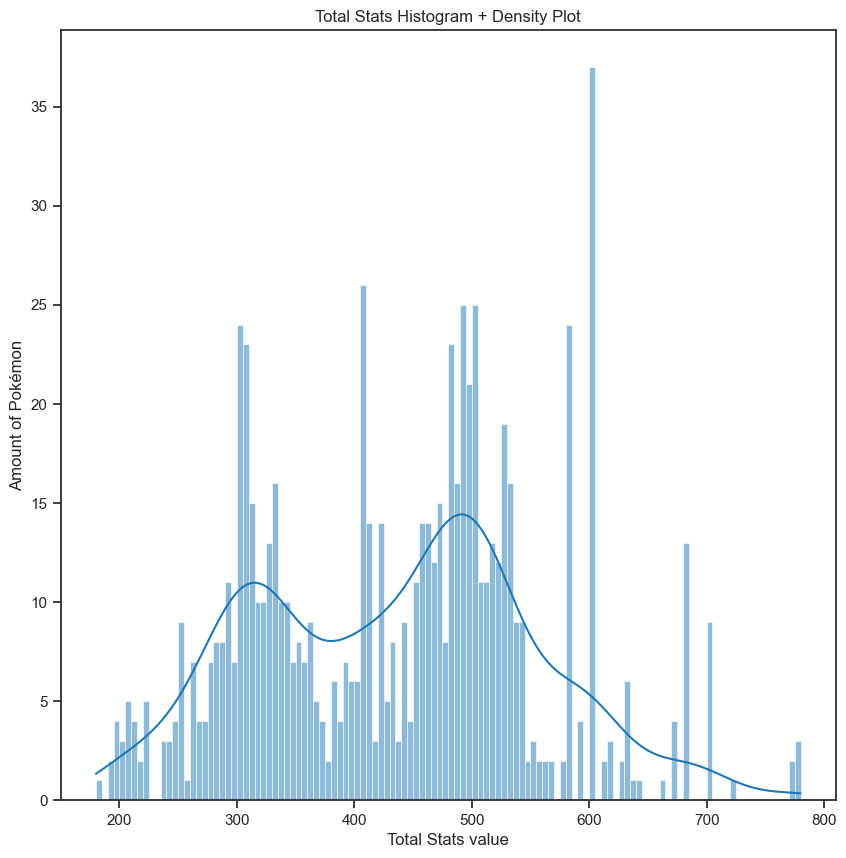

In [33]:
sns.set_theme(style="ticks", palette=None)
plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams['figure.dpi'] = 100

fig, ax = plt.subplots()

sns.histplot(data, x='TotalStats', bins=int((data['TotalStats'].max()-data['TotalStats'].min())/5), kde=True)  # kde=True adds a Kernel Density Estimation curve

# Show the plot
plt.xlabel("Total Stats value")
plt.ylabel("Amount of Pokémon")
plt.title("Total Stats Histogram + Density Plot")
plt.show()
fig.savefig('../Images/Graphics/TotalStastsHistDens.png', bbox_inches='tight')

<span style = "font-family: Verdana; font-size: 20px">

**Weight and Height**

In [ ]:
count = data.groupby(['Weight', 'Height'])['Weight'].transform('count')

fig = px.scatter(data, 
                 x = 'Weight', 
                 y = 'Height',
                 color = count,
                 title='Pokémon Weight vs Height',
                 log_x=True,
                 log_y=True,
                 labels = dict(
                     Weight = 'Weight (kg)',
                     Height = 'Height (m)',
                     color = 'Count'
                 ))

fig.update_layout(
    title = dict(
        text = '<br>Pokémon Weight vs Height Distribution',
        font = dict(size=16)
    ),
    xaxis_title = dict(text='Weight (kg)'),
    yaxis_title = dict(text='Height (m)'),
    title_x = 0.5,
    width = 1000,
    height = 600,
    coloraxis_showscale = False
)

fig.show()


<span style = "font-family: Verdana; font-size: 20px">

**Evolution Stages**

In [ ]:
evo_data = data[['EvoStage', 'TotalEvoStages']].copy()
evo_data['Evo'] = ''
evo_data.loc[(evo_data['EvoStage'] == 1) & (evo_data['TotalEvoStages'] == 1), 'Evo'] = '1 / 1 (No evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 1) & (evo_data['TotalEvoStages'] == 2), 'Evo'] = '1 / 2 (First stage of 2 evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 2) & (evo_data['TotalEvoStages'] == 2), 'Evo'] = '2 / 2 (Second stage of 2 evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 1) & (evo_data['TotalEvoStages'] == 3), 'Evo'] = '1 / 3 (First stage of 3 evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 2) & (evo_data['TotalEvoStages'] == 3), 'Evo'] = '2 / 3 (Second stage of 3 evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 3) & (evo_data['TotalEvoStages'] == 3), 'Evo'] = '3 / 3 (Third stage of 3 evolutions)'

evo_counts = evo_data['Evo'].value_counts().reset_index()

fig = go.Figure(data=[go.Pie(
    labels=evo_counts['Evo'],
    values=evo_counts['count'],
    hole=0.3,
    textposition='auto'
)])

fig.update_layout(
    title=dict(
        text='<br>Distribution of evolution stages of Pokémons',
        font=dict(size=16)
    ),
    title_x=0.5,
    showlegend=True
)

fig.show()

In [49]:
leveling_rate_counts = data['LevelingRate'].value_counts().reset_index()
leveling_rate_counts.columns

Index(['LevelingRate', 'count'], dtype='object')

<span style = "font-family: Verdana; font-size: 20px">

**Evolution Lines**

In [ ]:
nwk = nx.DiGraph()
# print(nwk.is_directed())

for i in range(len(data)):
    nwk.add_node(data["Name"][i])   # Add Pokémon's name nodes
    if data["PreevoName"][i] != "No Preevolution":
        nwk.add_edge(data["PreevoName"][i], data["Name"][i])
# print(nwk)

pos = nx.spring_layout(nwk)
# print(pos)

# Egde formation
edge_x = []
edge_y = []
# print(nwk.edges())
for edge in nwk.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)
    
edge_trace = go.Scatter(
    x = edge_x, y = edge_y,
    line = dict(
        width=0.5, 
        color='#000000'
        ),
    hoverinfo = 'none',
    mode = 'lines'
)

node_x = []
node_y = []
for node in nwk.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    
node_trace = go.Scatter(
    x = node_x, y = node_y,
    mode = 'markers',
    hoverinfo = 'text',
    marker=dict(
        showscale = True,
        colorscale = 'PuBu',
        reversescale = True,
        color = [],
        size = 10,
        colorbar = dict(
            title = dict(
                text = 'Node Connections',
                side = 'right'
            ),
            xanchor = 'left',
        ),
        line_width = 1
    )
)

print(nwk)

# Color node
node_adjacencies = []
node_text = []
for node, adjacencies in enumerate(nwk.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))
    node_text.append(f"Pokémon\'s name: {str(list(nwk)[node])}<br># of diffent evolutions: {str(len(adjacencies[1]))}")

node_trace.text = node_text
node_trace.marker.color = node_adjacencies #type: ignore

# Network
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title=dict(
                        text = '<br>Pokémon Evolution Network',
                        font = dict(size=16)
                    ),
                    showlegend = False,
                    hovermode = 'closest',
                    # marker = dict(
                    #     color = node_adjacencies
                    # ),
                    margin = dict(
                        b=20,l=5,r=5,t=40
                    ),
                    annotations=[
                        dict(
                            text = "Visualization Project",
                            showarrow = False,
                            xref = "paper",
                            yref = "paper",
                            x = 0.005,
                            y = -0.002
                        )
                    ],
                    xaxis = dict(
                        showgrid = False,
                        zeroline = False,
                        showticklabels = False
                    ),
                    yaxis = dict(
                        showgrid = False,
                        zeroline = False,
                        showticklabels = False
                    )
                )
            )
fig.update_layout(autosize = False,
                  width = 1000,
                  height = 1000)
fig.show()


DiGraph with 805 nodes and 413 edges


<span style = "font-family: Verdana; font-size: 20px">

**DamageFromTypes**

In [16]:
damage_cols = [col for col in data.columns if col.startswith('DamageFrom')]

for damage_col in damage_cols:
    type_name = damage_col.replace('DamageFrom', '')
    
    damage_counts = data[damage_col].value_counts().sort_index()
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=damage_counts.index,
        y=damage_counts.values,
        fill='tozeroy',
        mode='lines+markers',
        line=dict(color=COLOR_TYPES.get(type_name, '#000000'), width=2),
        marker=dict(size=8),
        name=type_name
    ))
    
    fig.update_layout(
        title=dict(
            text=f'<br>Distribution of Damage Multiplier from {type_name}',
            font=dict(size=16)
        ),
        xaxis_title=dict(text='Damage Multiplier'),
        yaxis_title=dict(text='Count'),
        title_x=0.5,
        xaxis=dict(
            tickmode='array',
            tickvals=[0, 0.25, 0.5, 1, 1.5, 2, 4]
        ),
        height=500,
        showlegend=False
    )
    
    fig.show()


<span style = "font-family: Verdana; font-size: 20px">

**Win Rate of Legendary/Mythical and Mega Evolutions vs Normal Pokémon**

In [ ]:
status_stats = data.copy()
status_stats['Status'] = np.select(
    [
        (status_stats['IsLegendary'] == 1),
        (status_stats['IsMythical'] == 1)
    ],
    [
        'Legendary',
        'Mythical'
    ],
    default='Normal'
)

winrate_stats = status_stats.groupby('Status').agg({
    'WinPercentage': 'mean',
    'FightsWon': 'sum',
    'TotalFights': 'sum'
}).reset_index()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=winrate_stats['Status'],
    y=winrate_stats['WinPercentage'],
    marker=dict(color=['#3498db', '#e74c3c', '#9b59b6']),
    text=winrate_stats['WinPercentage'].round(4),
    textposition='auto',
    texttemplate='%{text:.2%}'
))

fig.update_layout(
    title=dict(
        text='<br>Average Win Rate: Legendary & Mythical vs Normal Pokémon',
        font=dict(size=16)
    ),
    xaxis_title=dict(text='Pokémon Group'),
    yaxis_title=dict(text='Average Win Rate'),
    title_x=0.5,
    yaxis=dict(tickformat='.0%')
)

fig.show()

In [ ]:
mega_mask = (data['IsMega'] == 1) & (data['IsLegendary'] == 0) & (data['IsMythical'] == 0)
non_mega_mask = (data['IsMega'] == 0) & (data['IsLegendary'] == 0) & (data['IsMythical'] == 0)

mega_winrate = data.loc[mega_mask, 'WinPercentage'].mean()
non_mega_winrate = data.loc[non_mega_mask, 'WinPercentage'].mean()

winrate_df = pd.DataFrame({
    'Group': ['Mega Evolution', 'Other (Non-Legendary/Mythical)'],
    'Average Win Rate': [mega_winrate, non_mega_winrate]
})

fig = go.Figure(data=[go.Bar(
    x=winrate_df['Group'],
    y=winrate_df['Average Win Rate'],
    marker=dict(color=['#ea00ff', '#9fa19f']),
    text=winrate_df['Average Win Rate'].round(4),
    textposition='auto',
    texttemplate='%{text:.2%}'
)])

fig.update_layout(
    title=dict(
        text='<br>Average Win Rate: Mega Evolution vs Other Pokémon (Excluding Legendary/Mythical)',
        font=dict(size=16)
    ),
    xaxis_title=dict(text='Pokémon Group'),
    yaxis_title=dict(text='Average Win Rate'),
    title_x=0.5,
    yaxis=dict(tickformat='.0%')
)

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

##### **Categorical Features**

<span style = "font-family: Verdana; font-size: 20px">

**Type**

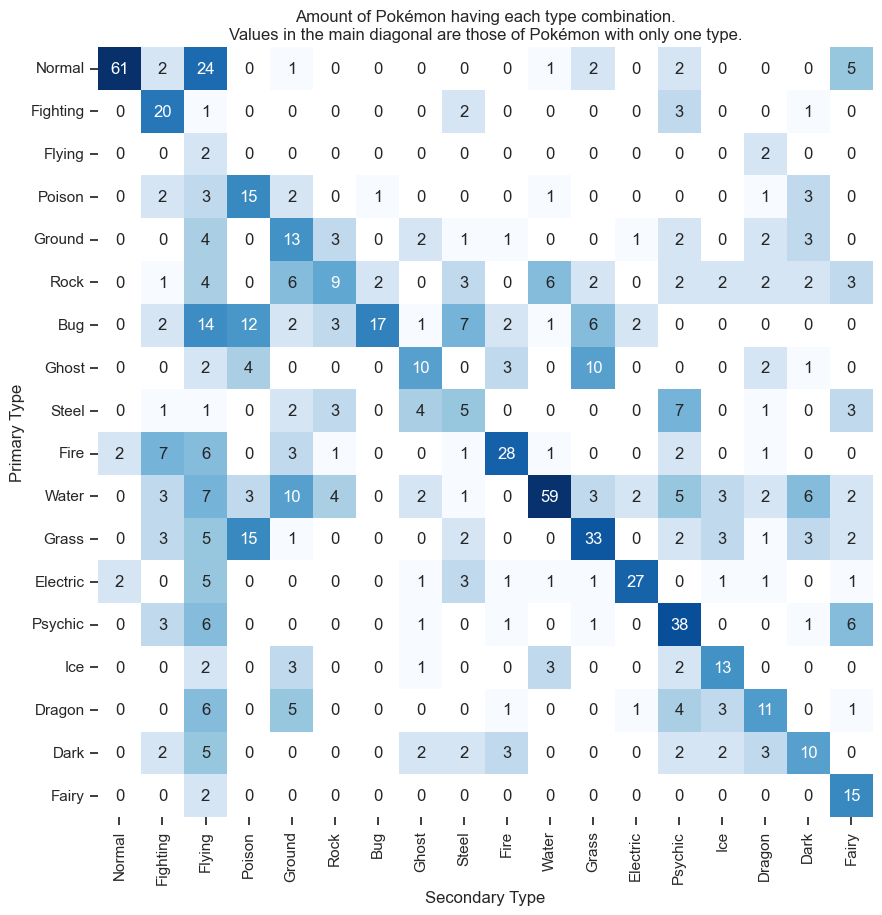

In [34]:
type_matrix = data.groupby(['Type1','Type2']).size().unstack(fill_value=0)
type_matrix = type_matrix[COLOR_TYPES.keys()].loc[COLOR_TYPES.keys()] #type: ignore
 
# mask = np.triu(np.ones(type_matrix.shape, dtype=bool), k=1)

cmap = plt.colormaps.get_cmap('Blues').copy()
cmap.set_bad('white')
cmap.set_under('white')

plt.title("Amount of Pokémon having each type combination.\nValues in the main diagonal are those of Pokémon with only one type.")
sns.heatmap(type_matrix, annot=True, cmap=cmap, norm=LogNorm(), cbar=False)
plt.ylabel("Primary Type")
plt.xlabel("Secondary Type")
plt.show()

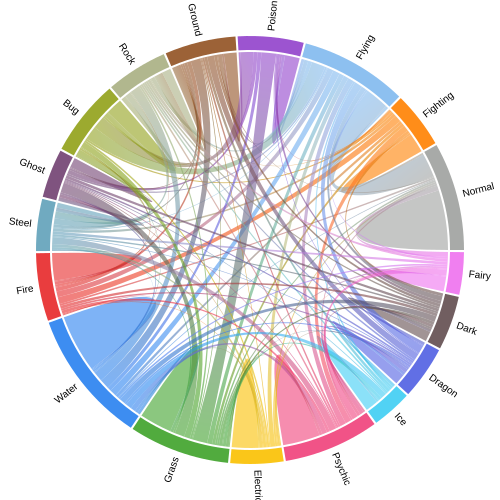

In [35]:
adjacency_matrix = type_matrix.copy()

for i in range(len(type_matrix)):
    for j in range(len(type_matrix)):
        if not j == i:
            adjacency_matrix.loc[type_matrix.keys()[i], type_matrix.keys()[j]] += type_matrix[type_matrix.keys()[i]][type_matrix.keys()[j]]


labels = list(COLOR_TYPES.keys())

fig = ocd.Chord(adjacency_matrix, labels)
fig.colormap = list(COLOR_TYPES.values())

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Abilities**

In [37]:
from tempfile import template


all_ability = []
for abi in ['Ability1', 'Ability2', 'HiddenAbility']:
    all_ability.extend(data[abi].unique().tolist())
    
all_ability = list(set(all_ability))
all_ability.remove('None')

print(f'Number of unique abilities: {len(all_ability)}')

all_ability_name_dict = {x: [] for x in all_ability}
for i in range(data.shape[0]):
    for abi_type in ['Ability1', 'Ability2', 'HiddenAbility']:
        x = data.at[i, abi_type]
        if not x == "None":
            all_ability_name_dict[x].append(data.at[i, 'Name'])
            
# print(all_ability_name_dict)

# Ability used by x Pokémon
amount_dict = {}
for  i in range(1, np.array([len(a) for a in all_ability_name_dict.values()]).max() + 1):
    amount_dict[i] = 0
    for key, value in all_ability_name_dict.items():
        if len(value) == i:
            amount_dict[i] += 1
            
# print(amount_dict)
for i in amount_dict.keys():
    print(i, [k for k, v in all_ability_name_dict.items() if len(v) == i]
)
    
df = pd.DataFrame(list(amount_dict.items()), columns=['Number of Pokémon', 'Number of Abilities'])

colorscale = 'Plasma'
normalized_heights = (df['Number of Abilities'] - df['Number of Abilities'].min()) / (df['Number of Abilities'].max() - df['Number of Abilities'].min()) # MinMaxScaling method

fig = go.Figure(data=[
        go.Bar(
            x = df['Number of Pokémon'],
            y = df['Number of Abilities'],
            marker = dict(
                color = normalized_heights,
                colorscale = colorscale,
                # showscale = True, # Interactive chart so unnessary
            )
        )
    ]
)

fig.update_layout(
    title = dict(
        text = f'<br>Number of Abilities used by certain number of Pokémon',
        font = dict(size=16)
    ),
    yaxis_title = dict(text='Number of Abilities'),
    xaxis_title = dict(text='Number of Pokémon'),
    title_x = 0.5,
    bargap = 0.1,
)

fig.show()
fig.write_image(f"../Images/Graphics/AbilitiesPokemon.png")

Number of unique abilities: 196
1 ['Desolate Land', 'Imposter', 'Air Lock', 'Bad Dreams', 'Power Construct', 'Slow Start', 'Multitype', 'Sharpness', 'Victory Star', 'Aura Break', 'Wind Rider', 'Fairy Aura', 'Parental Bond', 'Toxic Boost', 'Fur Coat', 'Color Change', 'Dark Aura', 'Flower Gift', 'Wonder Guard', 'Stall', 'Primordial Sea', 'Delta Stream', 'Forecast']
2 ['Honey Gather', 'Normalize', 'Iron Barbs', 'Multiscale', 'Heatproof', 'Turboblaze', 'Stance Change', 'White Smoke', 'Neutralizing Gas', 'Aerilate', 'Aroma Veil', 'Zen Mode', 'Mummy', 'Illusion', 'Sweet Veil', 'Flare Boost', 'Teravolt', 'Grass Pelt', 'Slush Rush', 'Defeatist']
3 ['Marvel Scale', 'Pixilate', 'Pure Power', 'Bulletproof', 'Flower Veil', 'Truant', 'Symbiosis', 'Gale Wings', 'Refrigerate', 'Magma Armor', 'Mega Launcher', 'Poison Heal', 'Drizzle', 'Cheek Pouch', 'Gooey', 'Strong Jaw', 'Immunity', 'Arena Trap', 'Filter']
4 ['Protean', 'Wonder Skin', 'Motor Drive', 'Download', 'Liquid Ooze', 'Solid Rock']
5 ['Heavy 

<span style = "font-family: Verdana; font-size: 20px">

**Pokémon Egg Group**

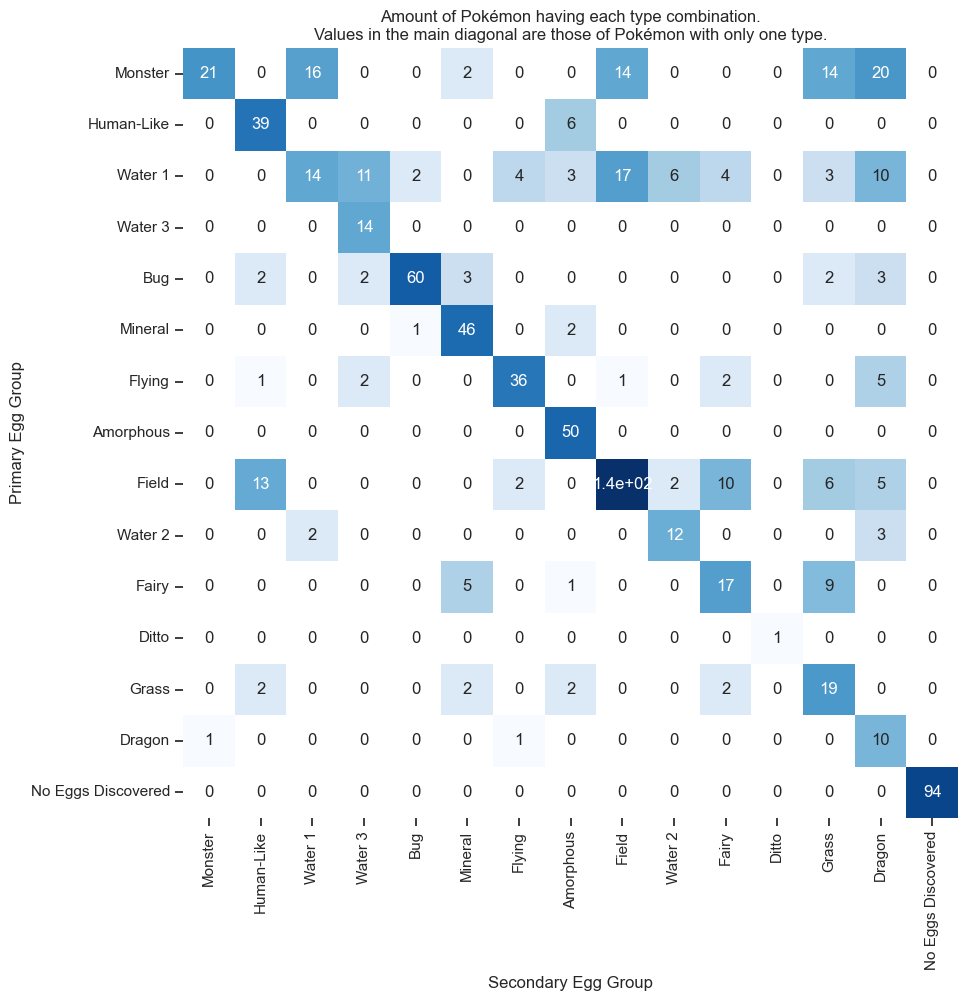

In [39]:
mask = (data['EggGroup2'] == 'No Eggs Discovered') & (data['EggGroup1'] != 'No Eggs Discovered')
data.loc[mask, 'EggGroup2'] = data.loc[mask, 'EggGroup1']
egg_matrix = data.groupby(['EggGroup1','EggGroup2']).size().unstack(fill_value=0)
egg_matrix = egg_matrix[COLOR_EGGGROUPS.keys()].loc[COLOR_EGGGROUPS.keys()] #type:ignore

cmap = plt.colormaps.get_cmap('Blues').copy()
cmap.set_bad('white')      # color of mask on heatmap
cmap.set_under('white')    # color of mask on cbar

plt.title("Amount of Pokémon having each type combination.\nValues in the main diagonal are those of Pokémon with only one type.")
sns.heatmap(egg_matrix, annot=True, cmap=cmap, norm=LogNorm(), cbar=False)
plt.ylabel("Primary Egg Group")
plt.xlabel("Secondary Egg Group")
plt.show()

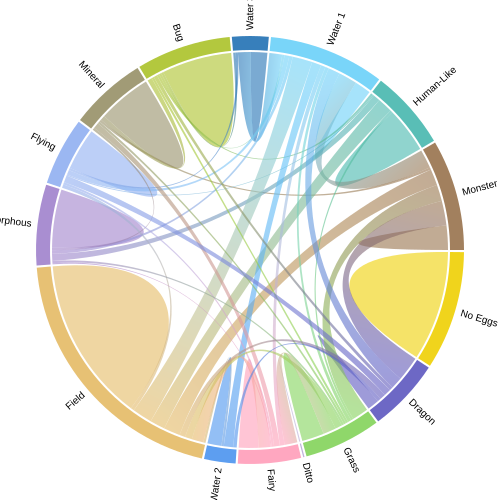

In [40]:
adjacency_matrix = egg_matrix.copy()

for i in range(len(egg_matrix)):
    for j in range(len(egg_matrix)):
        if not j == i:
            adjacency_matrix.loc[egg_matrix.keys()[i], egg_matrix.keys()[j]] += egg_matrix[egg_matrix.keys()[i]][egg_matrix.keys()[j]]


labels = list(COLOR_EGGGROUPS.keys())

fig = ocd.Chord(adjacency_matrix, labels)
fig.colormap = list(COLOR_EGGGROUPS.values())

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**LevelingRate**

In [41]:
leveling_rate_counts = data['LevelingRate'].value_counts().reset_index()
leveling_rate_counts.columns = ['LevelingRate', 'Count']

fig = go.Figure(data=[go.Pie(
    labels=leveling_rate_counts['LevelingRate'],
    values=leveling_rate_counts['Count'],
    hole=0.3,
    textinfo='label+percent',
    textposition='auto'
)])

fig.update_layout(
    title=dict(
        text='<br>Distribution of Pokémon by Leveling Rate',
        font=dict(size=16)
    ),
    title_x=0.5,
    showlegend=True
)

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Category**

In [15]:
category_counts = data['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

fig = go.Figure(data=[go.Bar(
    x=category_counts['Category'],
    y=category_counts['Count'],
    marker=dict(
        color=category_counts['Count'],
        showscale=False
    ),
    text=category_counts['Count'],
    textposition='auto'
)])

fig.update_layout(
    title=dict(
        text='<br>Number of Pokémon by Category',
        font=dict(size=16)
    ),
    xaxis_title=dict(text='Category'),
    yaxis_title=dict(text='Count'),
    title_x=0.5,
    xaxis=dict(tickangle=-45),
    height=600
)

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

##### **Binary Features**

<span style = "font-family: Verdana; font-size: 20px">

**Rarity**

In [ ]:
status_counts = {
    'Normal': (data['IsLegendary'] == 0) & (data['IsMythical'] == 0),
    'Legendary': (data['IsLegendary'] == 1),
    'Mythical': (data['IsMythical'] == 1)
}

status_df = pd.DataFrame({
    'Status': ['Normal', 'Legendary', 'Mythical'],
    'Count': [status_counts['Normal'].sum(), status_counts['Legendary'].sum(), status_counts['Mythical'].sum()]
})

fig = go.Figure(data=[go.Pie(
    labels=status_df['Status'],
    values=status_df['Count'],
    hole=0.3,
    textinfo='label+percent',
    textposition='auto'
)])

fig.update_layout(
    title=dict(
        text='<br>Distribution of Pokémon by Rarity',
        font = dict(size = 16),
        automargin=True
    ),
    title_x=0.5,
    showlegend=True,
)

fig.show()